In [ ]:
# Cell 1: Imports and Setup
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from datetime import datetime
import numpy as np
from scipy import stats
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
import scipy.stats as stats
import warnings
warnings.filterwarnings('ignore')


# Basic matplotlib settings
plt.rcParams['figure.figsize'] = (10, 6)
plt.rcParams['axes.grid'] = True
plt.rcParams['grid.alpha'] = 0.3
plt.rcParams['axes.labelsize'] = 12
plt.rcParams['axes.titlesize'] = 14
plt.rcParams['xtick.labelsize'] = 10
plt.rcParams['ytick.labelsize'] = 10

# Custom color scheme
colors = ['#1f77b4', '#ff7f0e', '#2ca02c', '#d62728', '#9467bd',
          '#8c564b', '#e377c2', '#7f7f7f', '#bcbd22', '#17becf']
plt.rcParams['axes.prop_cycle'] = plt.cycler(color=colors)


In [ ]:
# Data Loading
def load_data(file_path):
    """Load and prepare the Twitch data"""
    df = pd.read_csv(file_path, encoding='ISO-8859-1')  # 或使用 'latin1'
    df['date'] = pd.to_datetime(df[['Year', 'Month']].assign(DAY=1))
    return df


# Load the data
df = load_data('twitch_data.csv')
print("Data shape:", df.shape)
print("\nColumns:", df.columns.tolist())
print("\nSample data:")
display(df.head())


In [13]:
# Basic Statistics Function
def basic_statistics(df):
    """Generate basic statistics for the dataset"""
    numeric_cols = df.select_dtypes(include=[np.number]).columns
    stats = {
        'summary_stats': df[numeric_cols].describe(),
        'total_unique_games': df['Game'].nunique(),
        'date_range': (df['date'].min(), df['date'].max()),
        'total_hours_watched': df['Hours_watched'].sum(),
        'avg_monthly_viewers': df['Avg_viewers'].mean()
    }
    return stats

# Calculate and display basic statistics
stats = basic_statistics(df)
print("Dataset Summary:")
display(stats['summary_stats'])
print(f"\nTotal unique games: {stats['total_unique_games']}")
print(f"Date range: {stats['date_range'][0]} to {stats['date_range'][1]}")

Dataset Summary:


,Rank,Month,Year,Hours_watched,Hours_streamed,Peak_viewers,Peak_channels,Streamers,Avg_viewers,Avg_channels,Avg_viewer_ratio
count,21000.00000,21000.000000,21000.000000,2.100000e+04,2.100000e+04,2.100000e+04,21000.000000,2.100000e+04,21000.000000,21000.000000,21000.000000
mean,100.50000,6.371429,2019.885714,5.831853e+06,1.900508e+05,6.430924e+04,697.252524,2.365554e+04,7996.368762,260.118810,76.718188
std,57.73568,3.412264,2.527300,1.943051e+07,5.702921e+05,1.554388e+05,2652.329931,7.051357e+04,26647.637940,781.893539,411.475720
min,1.00000,1.000000,2016.000000,8.981100e+04,1.900000e+01,4.410000e+02,1.000000,0.000000e+00,120.000000,0.000000,1.400000
25%,50.75000,3.000000,2018.000000,5.430898e+05,1.597150e+04,1.004825e+04,66.000000,1.916000e+03,744.000000,21.000000,16.177500
50%,100.50000,6.000000,2020.000000,1.079297e+06,4.230250e+04,2.345950e+04,158.000000,5.374500e+03,1481.000000,57.000000,29.320000
75%,150.25000,9.000000,2022.000000,3.032041e+06,1.099875e+05,5.519000e+04,403.000000,1.438975e+04,4135.500000,151.000000,57.222500
max,200.00000,12.000000,2024.000000,3.445520e+08,1.024570e+07,3.915488e+06,129860.000000,1.728322e+06,479209.000000,13789.000000,29564.560000



Total unique games: 2359
Date range: 2016-01-01 00:00:00 to 2024-09-01 00:00:00



Top Games by Hours Watched:


Game
Just Chatting                       1.972256e+08
League of Legends                   1.075884e+08
VALORANT                            8.577524e+07
Fortnite                            7.154762e+07
Grand Theft Auto V                  7.125740e+07
Counter-Strike                      5.477473e+07
Counter-Strike: Global Offensive    4.848936e+07
Call of Duty: Warzone               4.458093e+07
Dota 2                              4.289303e+07
Apex Legends                        3.904723e+07
Name: Hours_watched, dtype: float64

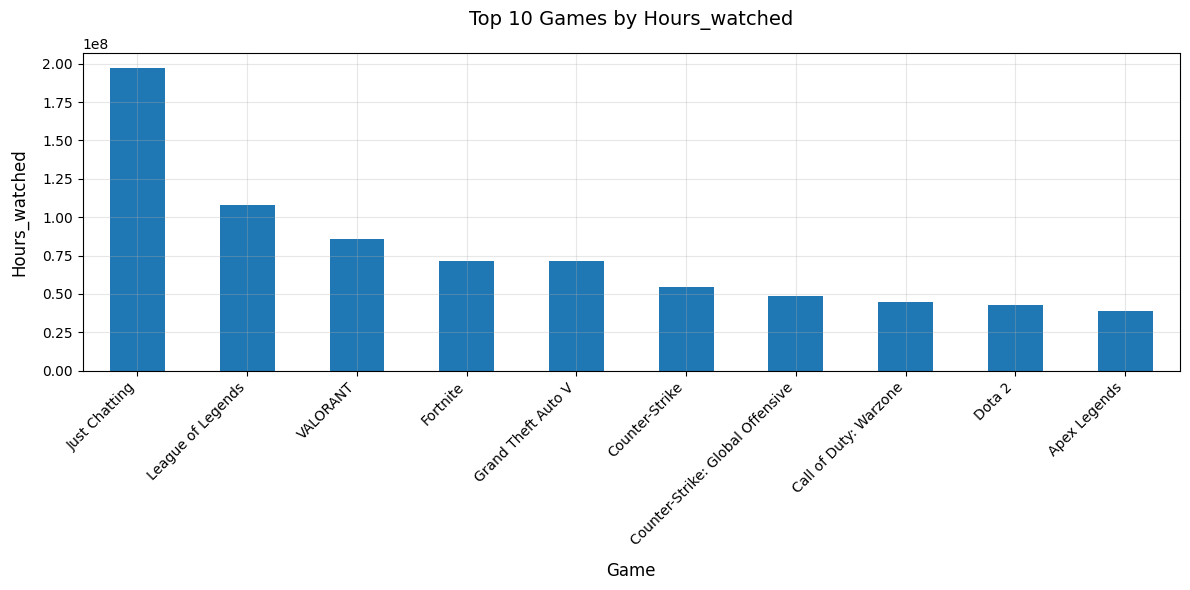

In [14]:
# Top Games Analysis
def analyze_top_games(df, metric='Hours_watched', n=10, year=None):
    """Analyze top games by specified metric"""
    if year:
        filtered_df = df[df['Year'] == year]
    else:
        filtered_df = df
        
    top_games = filtered_df.groupby('Game')[metric].mean().sort_values(ascending=False).head(n)
    
    fig = plt.figure(figsize=(12, 6))
    ax = fig.add_subplot(111)
    top_games.plot(kind='bar', ax=ax)
    plt.title(f'Top {n} Games by {metric}', pad=20)
    plt.xlabel('Game', labelpad=10)
    plt.ylabel(metric, labelpad=10)
    plt.xticks(rotation=45, ha='right')
    plt.tight_layout()
    
    return top_games, fig

# Analyze top games
top_games, top_games_fig = analyze_top_games(df)
print("\nTop Games by Hours Watched:")
display(top_games)

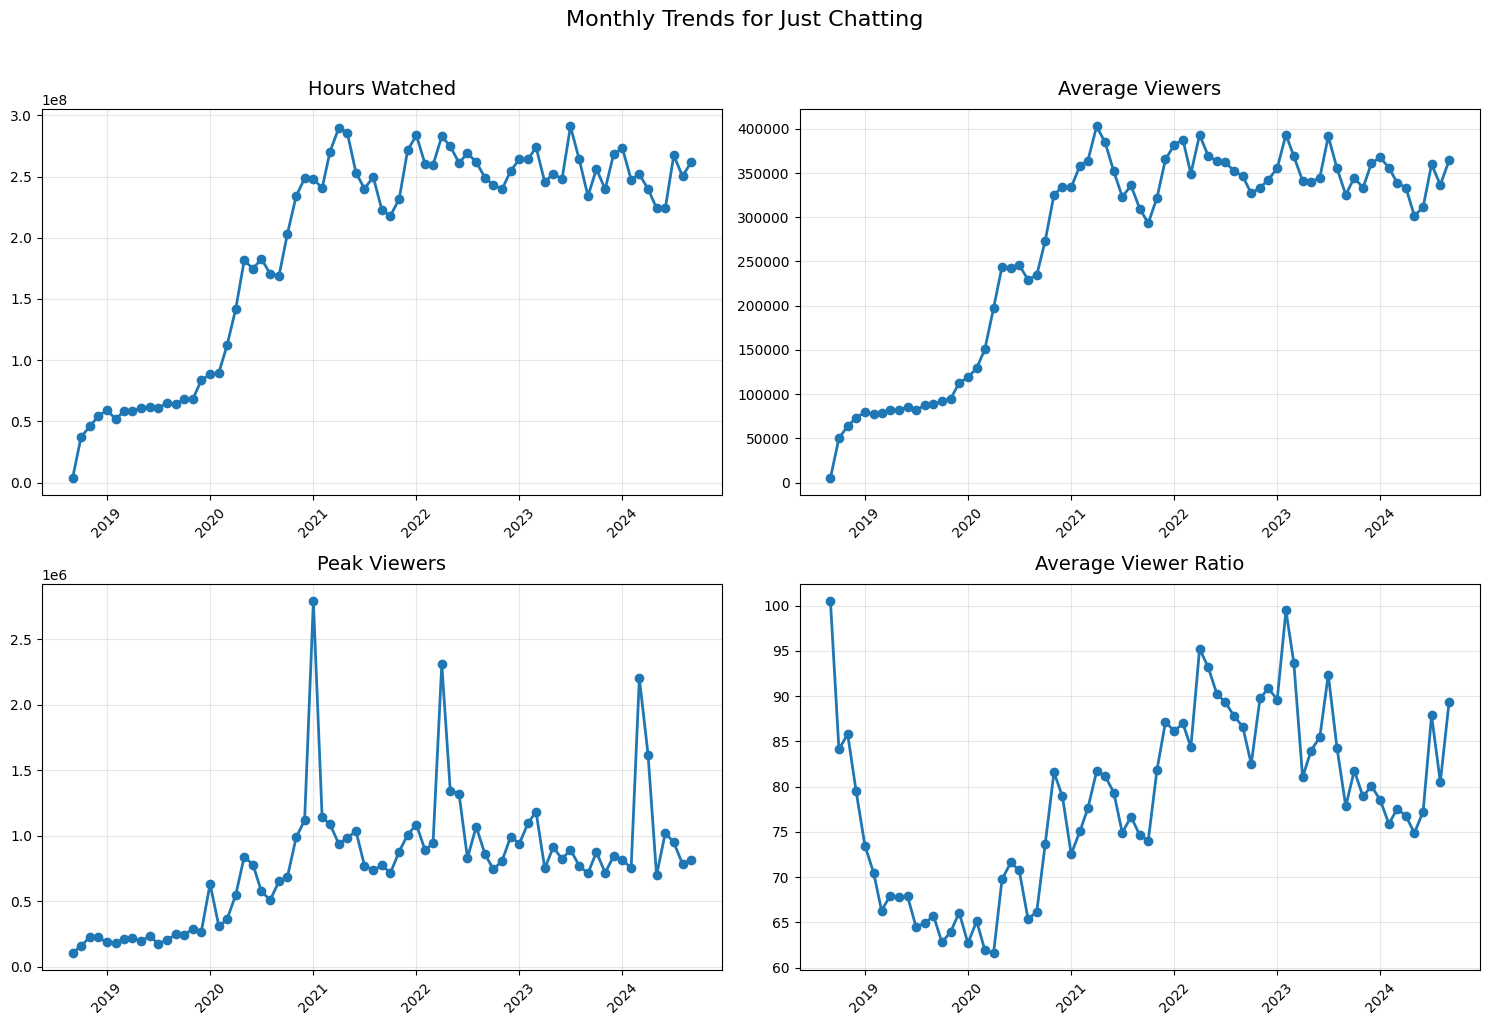

In [15]:
# Monthly Trends Analysis
def plot_game_trends(df, game_name):
    """Plot monthly trends for a specific game"""
    game_data = df[df['Game'] == game_name]
    
    fig = plt.figure(figsize=(15, 10))
    fig.suptitle(f'Monthly Trends for {game_name}', y=1.02, fontsize=16)
    
    metrics = [
        ('Hours_watched', 'Hours Watched', 221),
        ('Avg_viewers', 'Average Viewers', 222),
        ('Peak_viewers', 'Peak Viewers', 223),
        ('Avg_viewer_ratio', 'Average Viewer Ratio', 224)
    ]
    
    for metric, title, pos in metrics:
        ax = fig.add_subplot(pos)
        ax.plot(game_data['date'], game_data[metric], marker='o', linewidth=2)
        ax.set_title(title, pad=10)
        ax.tick_params(axis='x', rotation=45)
        ax.grid(True, alpha=0.3)
    
    plt.tight_layout()
    return fig

# Plot trends for the top game
top_game = top_games.index[0]
trends_fig = plot_game_trends(df, top_game)


Engagement Statistics:


Hours_watched                               \
                                 mean        std      min      max   
Game                                                                 
.hack//G.U. Last Recode     145350.00        NaN   145350   145350   
20 Minutes Till Dawn        911356.00        NaN   911356   911356   
2XKO                       2137305.00        NaN  2137305  2137305   
60 Parsecs!                 529688.00        NaN   529688   529688   
60 Seconds!                 314900.56  201154.78   109473   772786   

                        Peak_viewers                         Avg_viewers  \
                                mean       std    min    max        mean   
Game                                                                       
.hack//G.U. Last Recode      1222.00       NaN   1222   1222      202.00   
20 Minutes Till Dawn        29743.00       NaN  29743  29743     1267.00   
2XKO                        60961.00       NaN  60961  60961     2876.00   
60 Parsecs!                 31960.00       NaN  31960  31960      736.00   
60 Seconds!                 27022.22  15746.06   5297  56904      424.89   

                                 ... Avg_viewer_ratio         Hours_streamed  \
                            std  ...              min     max           mean   
Game                             ...                                           
.hack//G.U. Last Recode     NaN  ...             4.12    4.12       35258.00   
20 Minutes Till Dawn        NaN  ...            74.38   74.38       12253.00   
2XKO                        NaN  ...            66.91   66.91       31942.00   
60 Parsecs!                 NaN  ...           283.71  283.71        1867.00   
60 Seconds!              269.47  ...           195.93  450.17        1023.11   

                                             Peak_channels                  
                           std    min    max          mean   std  min  max  
Game                                                                        
.hack//G.U. Last Recode    NaN  35258  35258         258.0   NaN  258  258  
20 Minutes Till Dawn       NaN  12253  12253          80.0   NaN   80   80  
2XKO                       NaN  31942  31942         508.0   NaN  508  508  
60 Parsecs!                NaN   1867   1867          27.0   NaN   27   27  
60 Seconds!              620.8    503   2065          12.0  7.35    5   30  

[5 rows x 24 columns]

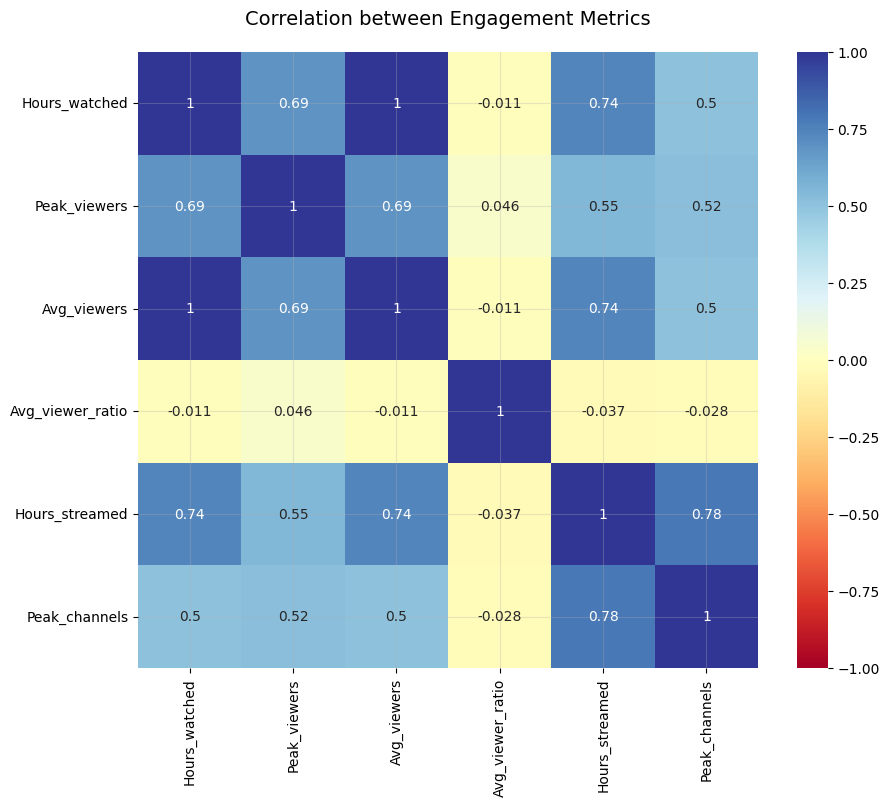

In [17]:

# Viewer Engagement Analysis
def analyze_engagement(df):
    """Analyze viewer engagement metrics"""
    engagement_metrics = ['Hours_watched', 'Peak_viewers', 'Avg_viewers', 
                        'Avg_viewer_ratio', 'Hours_streamed', 'Peak_channels']
    
    # Correlation analysis
    correlation_matrix = df[engagement_metrics].corr()
    
    fig = plt.figure(figsize=(10, 8))
    ax = fig.add_subplot(111)
    sns.heatmap(correlation_matrix, annot=True, cmap='RdYlBu', vmin=-1, vmax=1, ax=ax)
    plt.title('Correlation between Engagement Metrics', pad=20)
    
    # Calculate detailed metrics
    engagement_stats = df.groupby('Game')[engagement_metrics].agg([
        'mean', 'std', 'min', 'max'
    ]).round(2)
    
    return correlation_matrix, engagement_stats, fig

# Analyze engagement
corr_matrix, eng_stats, eng_fig = analyze_engagement(df)
print("\nEngagement Statistics:")
display(eng_stats.head())


Volatility Analysis:


rank_change                                     Rank  \
                              std count      mean    min   max        mean   
Game                                                                         
7 Days to Die           36.230641   104 -0.221154 -107.0  64.0  114.114286   
ARK: Survival Evolved   23.625269    71 -0.380282 -118.0  51.0   57.333333   
ASMR                    14.499629    72 -1.763889 -119.0  10.0   35.945205   
Age of Empires II       20.188424    93 -0.333333  -96.0  40.0  105.074468   
Age of Empires IV       30.338872    30  3.366667  -69.0  57.0  142.354839   

                                
                      min  max  
Game                            
7 Days to Die          27  192  
ARK: Survival Evolved  13  131  
ASMR                   21  156  
Age of Empires II      54  199  
Age of Empires IV      23  193

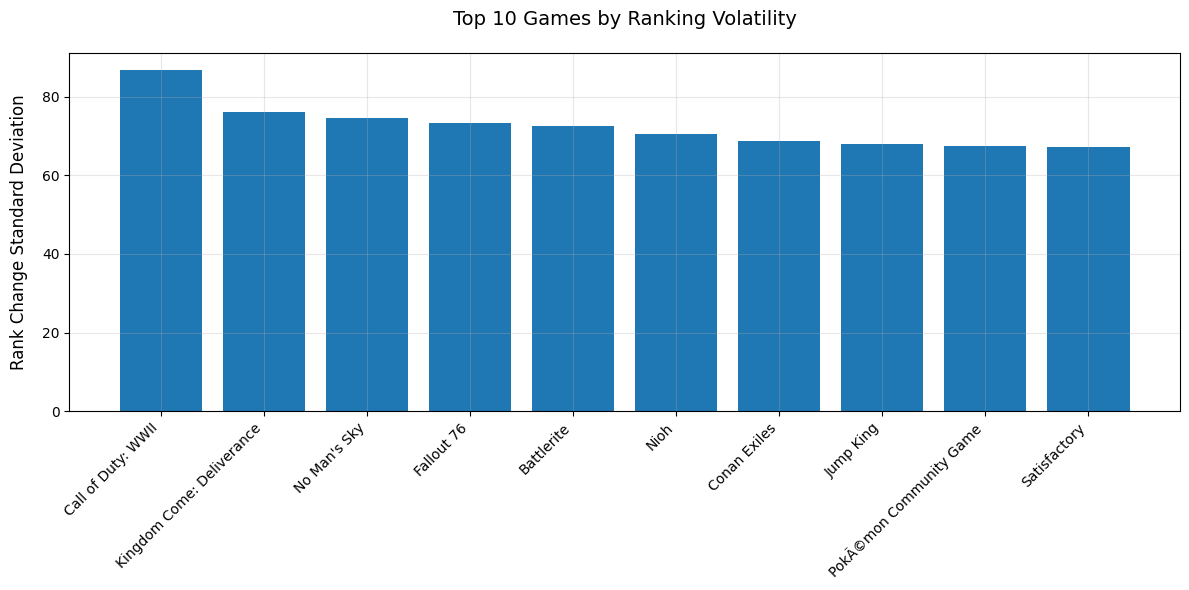

In [18]:


# Game Volatility Analysis
def analyze_volatility(df):
    """Analyze ranking volatility of games"""
    # Calculate rank changes
    df['rank_change'] = df.groupby('Game')['Rank'].diff()
    
    volatility = df.groupby('Game').agg({
        'rank_change': ['std', 'count', 'mean', 'min', 'max'],
        'Rank': ['mean', 'min', 'max']
    }).fillna(0)
    
    volatility = volatility[volatility[('rank_change', 'count')] > 12]
    
    # Visualization
    fig = plt.figure(figsize=(12, 6))
    ax = fig.add_subplot(111)
    top_volatile = volatility['rank_change']['std'].nlargest(10)
    ax.bar(range(len(top_volatile)), top_volatile.values)
    ax.set_xticks(range(len(top_volatile)))
    ax.set_xticklabels(top_volatile.index, rotation=45, ha='right')
    plt.title('Top 10 Games by Ranking Volatility', pad=20)
    plt.ylabel('Rank Change Standard Deviation', labelpad=10)
    plt.tight_layout()
    
    return volatility, fig

# Analyze volatility
volatility_data, vol_fig = analyze_volatility(df)
print("\nVolatility Analysis:")
display(volatility_data.head())


Clustering Results:


,Hours_watched,Peak_viewers,Avg_viewers,Avg_viewer_ratio,Cluster
Game,,,,,
.hack//G.U. Last Recode,1.453500e+05,1222.000000,202.000000,4.120000,0
20 Minutes Till Dawn,9.113560e+05,29743.000000,1267.000000,74.380000,0
2XKO,2.137305e+06,60961.000000,2876.000000,66.910000,0
60 Parsecs!,5.296880e+05,31960.000000,736.000000,283.710000,0
60 Seconds!,3.149006e+05,27022.222222,424.888889,313.857778,0


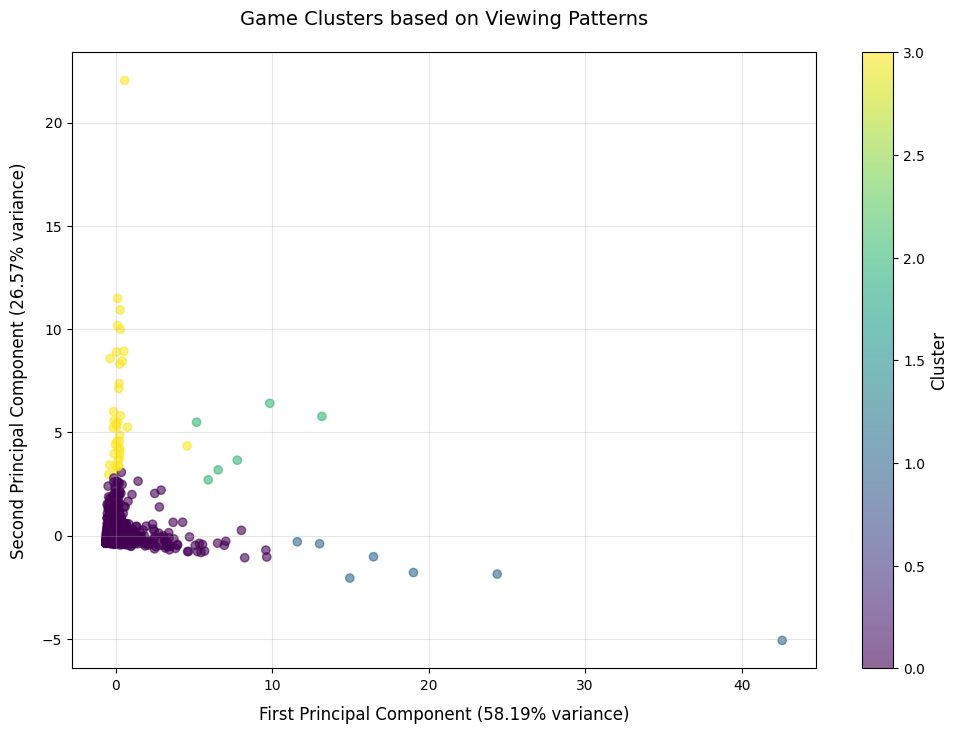

In [19]:


# Cluster Analysis
def perform_clustering(df, n_clusters=4):
    """Perform cluster analysis on games"""
    metrics = ['Hours_watched', 'Peak_viewers', 'Avg_viewers', 'Avg_viewer_ratio']
    avg_metrics = df.groupby('Game')[metrics].mean()
    
    # Standardize features
    scaler = StandardScaler()
    scaled_features = scaler.fit_transform(avg_metrics)
    
    # Clustering
    kmeans = KMeans(n_clusters=n_clusters, random_state=42)
    clusters = kmeans.fit_predict(scaled_features)
    
    # PCA for visualization
    pca = PCA(n_components=2)
    pca_result = pca.fit_transform(scaled_features)
    
    # Visualization
    fig = plt.figure(figsize=(12, 8))
    ax = fig.add_subplot(111)
    scatter = ax.scatter(pca_result[:, 0], pca_result[:, 1], 
                        c=clusters, cmap='viridis', alpha=0.6)
    plt.title('Game Clusters based on Viewing Patterns', pad=20)
    plt.xlabel(f'First Principal Component ({pca.explained_variance_ratio_[0]:.2%} variance)',
              labelpad=10)
    plt.ylabel(f'Second Principal Component ({pca.explained_variance_ratio_[1]:.2%} variance)',
              labelpad=10)
    plt.colorbar(scatter, label='Cluster')
    
    # Add cluster information to metrics
    avg_metrics['Cluster'] = clusters
    return avg_metrics, fig

# Perform clustering
cluster_results, cluster_fig = perform_clustering(df)
print("\nClustering Results:")
display(cluster_results.head())


Growth Analysis:


,growth_rate,r_squared,p_value,avg_hours,total_months
League of Legends,14227.461147,0.207849,1.022480e-06,1.075884e+08,105.0
Counter-Strike: Global Offensive,11914.756555,0.239003,1.168176e-06,4.848936e+07,89.0
Dota 2,2893.064236,0.052448,1.877674e-02,4.289303e+07,105.0
Hearthstone,-9790.488903,0.742409,4.175329e-32,2.393523e+07,105.0
Call of Duty: Black Ops III,-3295.705845,0.259483,2.996897e-04,3.332854e+06,46.0


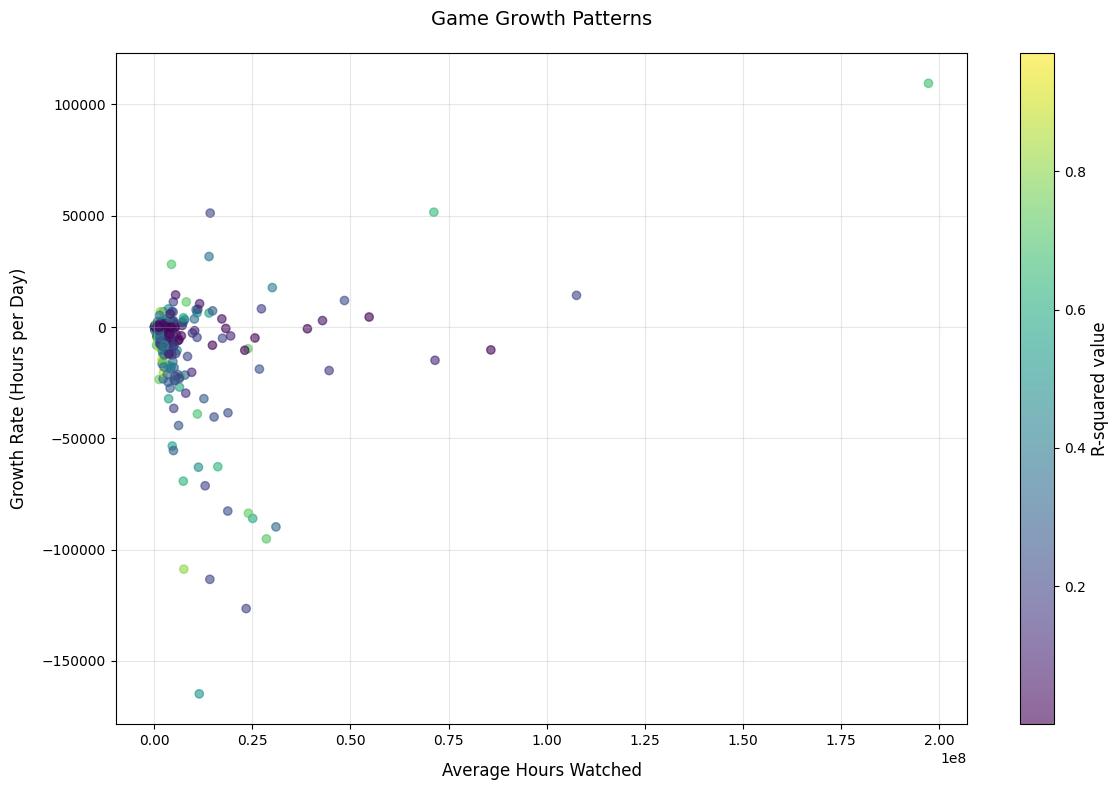

In [24]:
# Growth Analysis
def analyze_growth(df):
    """Analyze growth trajectories of games"""
    growth_data = {}
    
    for game in df['Game'].unique():
        game_data = df[df['Game'] == game]
        if len(game_data) < 6:
            continue
            
        X = (game_data['date'] - game_data['date'].min()).dt.days.values.reshape(-1, 1)
        y = game_data['Hours_watched'].values
        
        # Perform linear regression using scipy.stats.linregress
        slope, intercept, r_value, p_value, std_err = stats.linregress(X.flatten(), y)
        
        growth_data[game] = {
            'growth_rate': slope,
            'r_squared': r_value**2,
            'p_value': p_value,
            'avg_hours': game_data['Hours_watched'].mean(),
            'total_months': len(game_data)
        }
    
    growth_df = pd.DataFrame(growth_data).T
    
    # Visualization
    fig = plt.figure(figsize=(12, 8))
    ax = fig.add_subplot(111)
    scatter = ax.scatter(
        growth_df['avg_hours'], 
        growth_df['growth_rate'], 
        c=growth_df['r_squared'], 
        cmap='viridis',
        alpha=0.6
    )
    plt.colorbar(scatter, label='R-squared value')
    plt.xlabel('Average Hours Watched', labelpad=10)
    plt.ylabel('Growth Rate (Hours per Day)', labelpad=10)
    plt.title('Game Growth Patterns', pad=20)
    plt.tight_layout()
    
    return growth_df, fig

# Analyze growth
growth_results, growth_fig = analyze_growth(df)
print("\nGrowth Analysis:")
display(growth_results.head())


Seasonal Analysis:


Hours_watched              Peak_viewers            Avg_viewers          
               mean          std         mean        std        mean       std
Month                                                                         
1        5967013.03  20349585.67     76809.33  155079.48     8030.47  27388.40
2        5528643.37  18818154.81     57036.40  128492.19     8155.51  27793.42
3        5890985.33  19930285.01     61812.22  144553.71     7928.15  26824.07
4        6040685.04  21500335.62     59060.04  140461.60     8401.01  29903.11
5        6137817.03  20921005.56     60217.81  136512.59     8260.35  28157.47

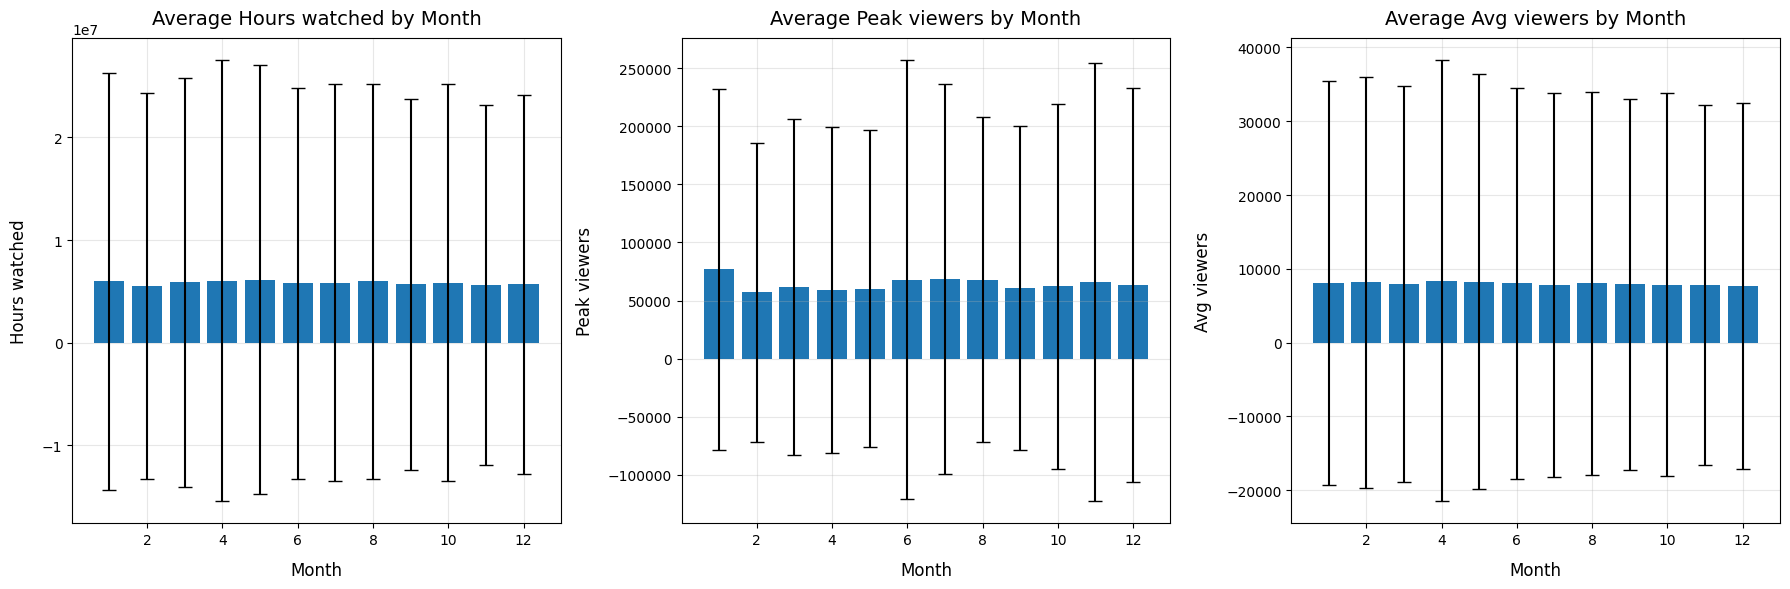

In [26]:


# Seasonal Analysis
def analyze_seasonality(df):
    """Analyze seasonal patterns in viewership"""
    monthly_stats = df.groupby('Month').agg({
        'Hours_watched': ['mean', 'std'],
        'Peak_viewers': ['mean', 'std'],
        'Avg_viewers': ['mean', 'std']
    }).round(2)
    
    fig = plt.figure(figsize=(18, 6))
    metrics = ['Hours_watched', 'Peak_viewers', 'Avg_viewers']
    
    for i, metric in enumerate(metrics, 1):
        ax = fig.add_subplot(1, 3, i)
        means = monthly_stats[metric]['mean']
        stds = monthly_stats[metric]['std']
        
        ax.bar(range(1, 13), means, yerr=stds, capsize=5)
        ax.set_title(f'Average {metric.replace("_", " ")} by Month', pad=10)
        ax.set_xlabel('Month', labelpad=10)
        ax.set_ylabel(metric.replace('_', ' '), labelpad=10)
        ax.grid(True, alpha=0.3)
    
    plt.tight_layout()
    return monthly_stats, fig

# Analyze seasonality
seasonal_stats, seasonal_fig = analyze_seasonality(df)
print("\nSeasonal Analysis:")
display(seasonal_stats.head())


